In [1]:
from plntxps import *
import pandas as pd

# set up experiment table

In [2]:
make_experiment_table('xps spectra/', 'experiment table.csv')

In [3]:
experiment_table = read_experiment_table('experiment table.csv')

In [4]:
make_spectrum_lists(experiment_table, 'spectrum lists')

# plot some example spectra

In [5]:
def get_data(label):
    return experiment_table.query('label == @label')['data'].item().spectra

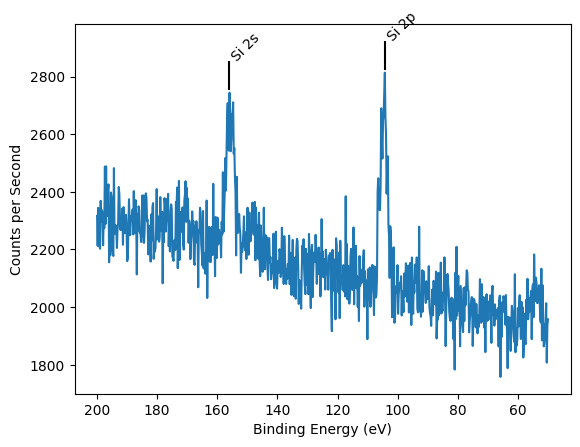

In [6]:
line, = get_data('3 hr treated 2')[1].plot()
plot_peaks(
    'Si', line, 10, 100, minimum_distance=2, shift = 5,
    color = 'black'
)
boilerplate()

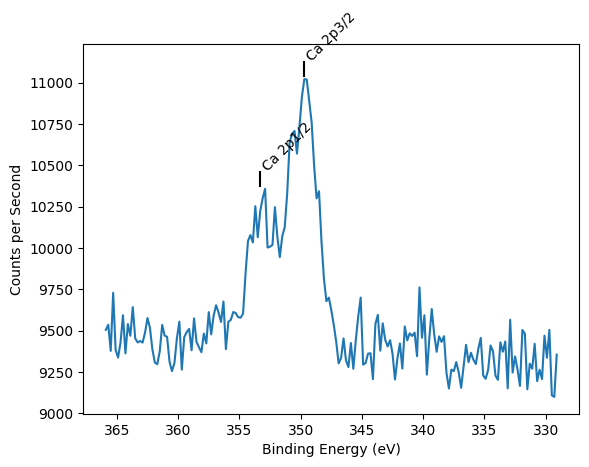

In [7]:
line, = get_data('3 hr treated 2')[2].plot()
plot_peaks(
    'Ca', line, 10, 100, minimum_distance=2, shift = 3,
    color = 'black', hover_range=1
)
boilerplate()

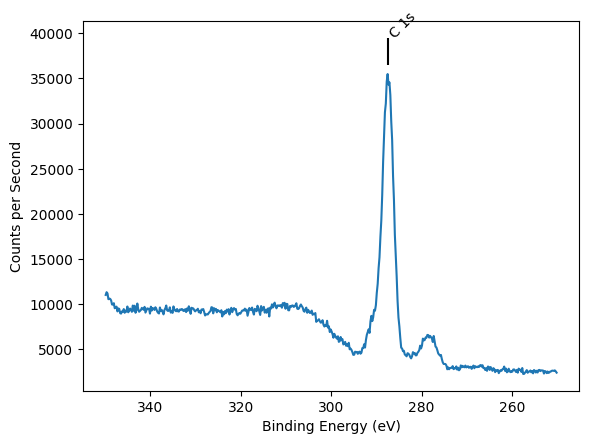

In [8]:
line, = get_data('3 hr treated 2')[3].plot()
plot_peaks(
    'C', line, 1000, 3000, minimum_distance = 2, shift = 3,
    color = 'black'
)
boilerplate()

# set up region table

In [9]:
make_blank_region_table('region table.csv')

In [10]:
region_table = pd.read_csv('region table.csv', sep = '\t')

In [11]:
make_empty_peak_tables(region_table, 'peaks')

In [12]:
peak_tables = read_peak_tables(region_table)

# make fit table

In [13]:
make_fit_table(experiment_table, region_table, 'fit table.csv')
fit_table = pd.read_csv('fit table.csv', sep = '\t')

# setup overrides

In [14]:
overrides = read_overrides('overrides/')

# make params files

In [15]:
satellites = get_satellites('Mg')

In [16]:
make_params_files(region_table, peak_tables, satellites)

# guinea pigs

In [17]:
batch_fit = XpsBatchFit(
    experiment_table,
    region_table,
    fit_table,
    peak_tables,
    overrides,
    satellites
)

## C 1s

In [18]:
calculate_gaussian_sigma(0.7, 2.012)

np.float64(0.9046517177649089)

resolution: 2.012077838904019


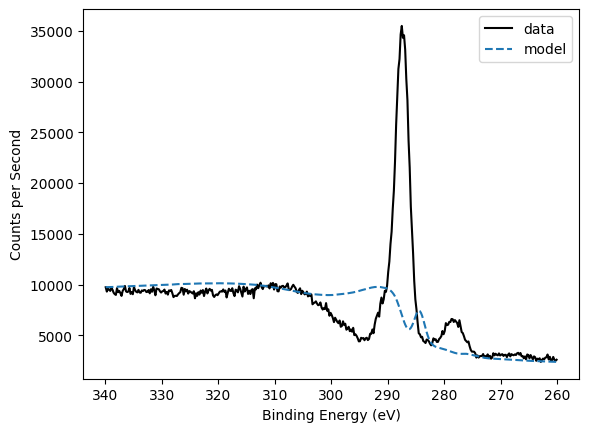

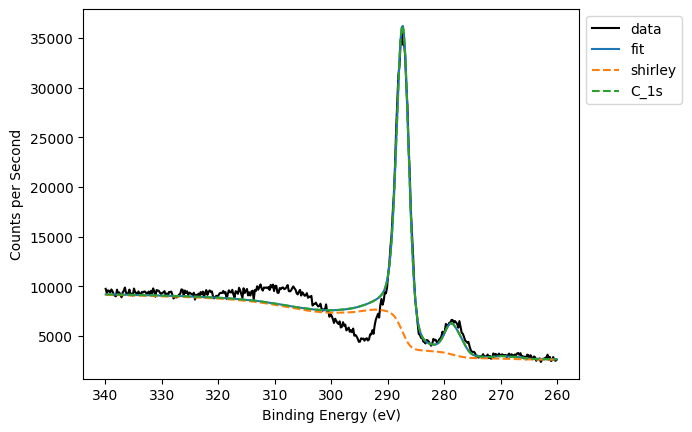

In [19]:
result = batch_fit.check_guess('3 hr treated 2', 'C 1s')

## Si

In [20]:
get_core_peaks_around(129).query("Element == 'Si'")

,Element,Level,Binding Energy
23,Si,2p3/2,99.0
21,Si,2p,99.3
22,Si,2p1/2,100.0
20,Si,2s,151.0


resolution: 2.012077838904019


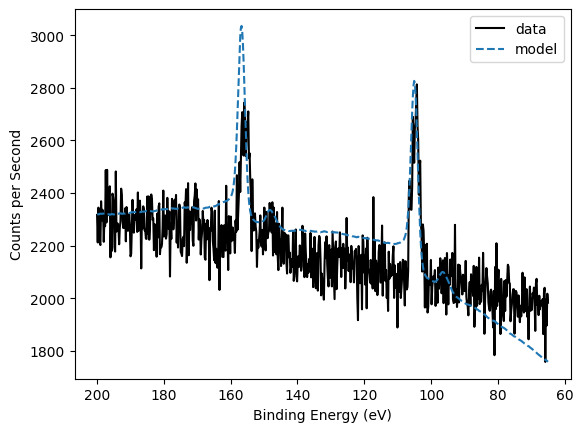

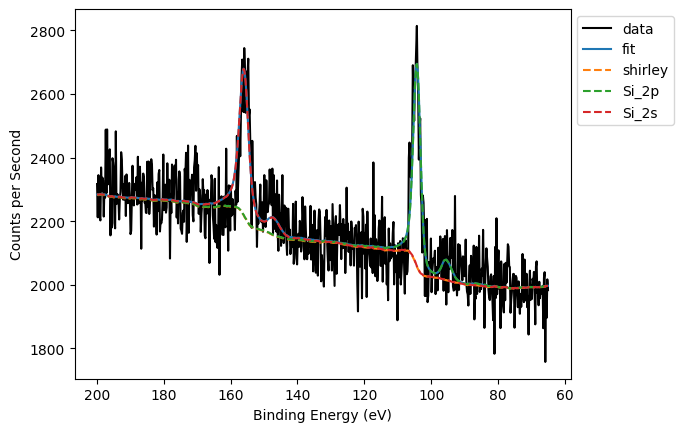

In [21]:
result = batch_fit.check_guess('3 hr treated 2', 'Si')

## Ca 2p

In [22]:
get_core_peaks_around(350).query('Element == "Ca"')

,Element,Level,Binding Energy
52,Ca,2p3/2,346.7
685,Ca,2p,347.9
51,Ca,2p1/2,350.3


resolution: 2.012077838904019


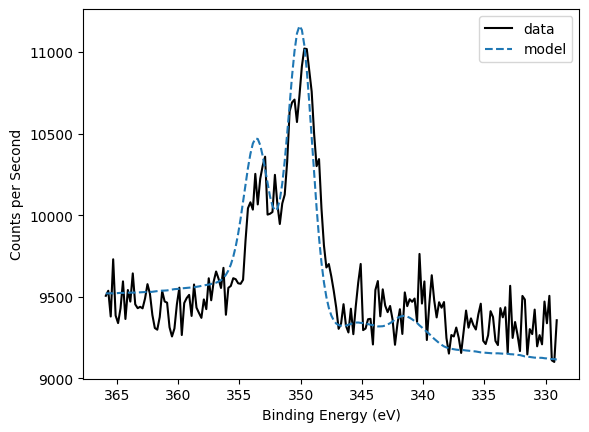

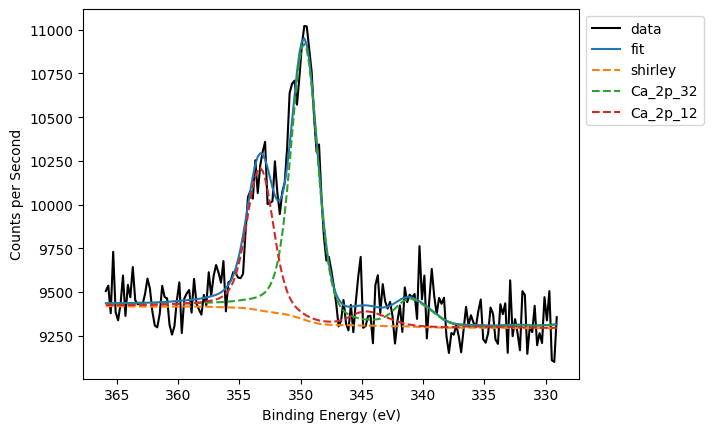

In [23]:
result = batch_fit.check_guess('3 hr treated 2', 'Ca 2p')

# do batch fit

In [24]:
batch_fit.do_batch_fit('fit results', logger = PrintLogger())

starting fit of C 1s
	starting fit of first sample
